# YieldSAT Dataset Walkthrough

This notebook accompanies the YieldSAT CVPR paper and project page: <https://yieldsat.github.io/>.

It is organized around the two dataset releases that are currently shared:

1. `original-preprocessed/` contains the raw per-field files, grouped by country and then by field.
2. `preprocessed-24-ts/` contains one model-ready NetCDF file per country.

The examples below use the current Germany release:

- Raw field example: `original-preprocessed/Germany/Germany_DUP3_farm5_field263_rapeseed_2019/`
- Preprocessed example: `preprocessed-24-ts/Germany/merge_s2-soil-dem-weather-coords.nc`


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import xarray as xr

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.max_columns = 200
pd.options.display.width = 120


def open_raster(raster_path):
    with rasterio.open(raster_path) as src:
        raster = src.read(1).astype(np.float32)
        if src.nodata is not None:
            raster[raster == src.nodata] = np.nan
    return raster


def read_rgb(raster_path):
    with rasterio.open(raster_path) as src:
        rgb = src.read([4, 3, 2]).astype(np.float32)
    rgb = np.moveaxis(rgb, 0, -1)
    scale = np.nanpercentile(rgb, 98)
    if not np.isfinite(scale) or scale == 0:
        scale = 1.0
    return np.clip(rgb / scale, 0, 1)


def decode_mapping(attrs):
    mapping = {}
    for key, value in attrs.items():
        try:
            mapping[int(key)] = value
        except (TypeError, ValueError):
            mapping[key] = value
    return mapping

## Configuration

Set the local dataset root once. The notebook then derives the raw and preprocessed example paths from it.


In [2]:
DATA_ROOT = Path("/yieldsat_data") # update this to path where you organize the data
RAW_ROOT = DATA_ROOT / "original-preprocessed"
PREPROCESSED_ROOT = DATA_ROOT / "preprocessed-24-ts"

COUNTRY = "Germany"
FIELD_ID = "Germany_DUP3_farm5_field263_rapeseed_2019"

field_root = RAW_ROOT / COUNTRY / FIELD_ID
preprocessed_path = PREPROCESSED_ROOT / COUNTRY / "merge_s2-soil-dem-weather-coords.nc"

assert RAW_ROOT.exists(), RAW_ROOT
assert PREPROCESSED_ROOT.exists(), PREPROCESSED_ROOT
assert field_root.exists(), field_root
assert preprocessed_path.exists(), preprocessed_path

## 1. Release Overview

The raw release is stored as `country -> field -> files`. The preprocessed release is stored as `country -> merge_s2-soil-dem-weather-coords.nc`.


In [3]:
raw_field_counts = {
    country_path.name: sum(1 for item in country_path.iterdir() if item.is_dir())
    for country_path in sorted(RAW_ROOT.iterdir())
    if country_path.is_dir()
}

preprocessed_files = {
    country_path.name: sorted(item.name for item in country_path.iterdir())
    for country_path in sorted(PREPROCESSED_ROOT.iterdir())
    if country_path.is_dir()
}

summary_rows = []
for country, field_count in raw_field_counts.items():
    summary_rows.append(
        {
            "country": country,
            "raw_field_directories": field_count,
            "preprocessed_files": ", ".join(preprocessed_files[country]),
        }
    )

pd.DataFrame(summary_rows).sort_values("country").reset_index(drop=True)

,country,raw_field_directories,preprocessed_files
0,Argentina,751,merge_s2-soil-dem-weather-coords.nc
1,Brazil,551,merge_s2-soil-dem-weather-coords.nc
2,Germany,299,merge_s2-soil-dem-weather-coords.nc
3,Uruguay,572,merge_s2-soil-dem-weather-coords.nc


## 2. Preprocessed Release

### NetCDF Data Format Overview

Each country is provided as a separate NetCDF file. These files store the model-ready representation used for benchmarking.

#### Key Components

- **`sample`**  
  The fused model input tensor with shape `(index, time_step, band)`.

- **`target`**  
  Pixel-level yield target values.

- **`row`, `col`, `field_shared_name`**  
  These variables allow reconstruction of individual fields from the flattened `index` dimension.

- **Categorical Variables**  
  Variables such as `crop`, `country`, `farm_identifier`, `year`, and `field_shared_name` are integer-encoded.  
  The corresponding mappings are stored in the variable attributes.

---

### Xarray Data Format for Pixel-Wise Yield Prediction

The Xarray (NetCDF) format is a processed version of the YieldSAT dataset, designed for training deep learning models at the pixel level.

- Uses a unified time series of **24 time steps** across all data modalities.
- Modalities are aligned in both **time and space** using:
  - Concatenation
  - Spatial repetition (input fusion)
- Each country file contains **all crop types** available within that country.
- Processing details are described in the main paper.

For more information on Xarray:  
https://docs.xarray.dev/en/latest/index.html

---

#### Coordinates

- **`band`** — Input modalities (e.g., Sentinel-2 + auxiliary data)  
- **`index`** — Pixel index  
- **`time_step`** — Temporal dimension  

---

#### Data Variables

- **`sample`** — Multimodal time series input `(index, time_step, band)`  
- **`target`** — Target yield value  
- **`row`** — Row index in the image for `index_i`  
- **`col`** — Column index in the image for `index_i`  
- **`crop`** — Crop type information  
- **`farm_identifier`** — Unique ID for a farm (region)  
- **`seeding_date`** — Seeding date for `index_i`  
- **`harvesting_date`** — Harvesting date for `index_i`  
- **`year`** — Year of harvest  

---

#### Attributes

- Contains additional metadata for each field  


In [4]:
ds = xr.open_dataset(preprocessed_path)
ds

<xarray.Dataset>
Dimensions:            (index: 609645, time_step: 24, band: 120)
Coordinates:
  * index              (index) object '5d35849b-ace1-4dd4-962d-da80c6c56bac' ...
  * time_step          (time_step) int64 0 1 2 3 4 5 6 ... 17 18 19 20 21 22 23
  * band               (band) object 'B01' 'B02' 'B03' ... 'coord_y' 'coord_z'
Data variables: (12/17)
    target             (index) float32 ...
    times              (index, time_step) datetime64[ns] ...
    seeding_date       (index) uint8 ...
    harvesting_date    (index) uint8 ...
    farm_identifier    (index) uint8 ...
    country            (index) uint8 ...
    ...                 ...
    col                (index) uint8 ...
    stats-mean         (band) float32 ...
    stats-min          (band) float32 ...
    stats-max          (band) float32 ...
    stats-std          (band) float32 ...
    sample             (index, time_step, band) float32 ...
Attributes: (12/299)
    Germany_DUP3_farm5_field265_rapeseed_2020_<>_yield_ground_truth:  2.892
    Germany_DUP3_farm2_field170_wheat_2019_<>_yield_ground_truth:     9.16
    Germany_DUP3_farm1_field13_rapeseed_2016_<>_yield_ground_truth:   3.03555...
    Germany_DUP3_farm1_field52_wheat_2019_<>_yield_ground_truth:      7.45555...
    Germany_DUP3_farm2_field128_wheat_2019_<>_yield_ground_truth:     7.94
    Germany_DUP3_farm6_field285_rapeseed_2020_<>_yield_ground_truth:  3.87
    ...                                                               ...
    Germany_DUP3_farm5_field269_rapeseed_2017_<>_yield_ground_truth:  2.205
    Germany_DUP3_farm2_field105_wheat_2019_<>_yield_ground_truth:     9.84
    Germany_DUP3_farm6_field281_rapeseed_2019_<>_yield_ground_truth:  3.74
    Germany_DUP3_farm2_field99_wheat_2018_<>_yield_ground_truth:      7.65
    Germany_DUP3_farm5_field275_rapeseed_2018_<>_yield_ground_truth:  4.454
    Germany_DUP3_farm6_field278_rapeseed_2018_<>_yield_ground_truth:  3.8

In [5]:
print("Dimensions")
print(pd.Series({name: int(size) for name, size in ds.sizes.items()}, name="size").to_string())

variable_summary = pd.DataFrame(
    [
        {
            "variable": name,
            "dims": ", ".join(data_array.dims),
            "shape": tuple(int(v) for v in data_array.shape),
            "dtype": str(data_array.dtype),
        }
        for name, data_array in ds.data_vars.items()
    ]
).sort_values("variable").reset_index(drop=True)

variable_summary

Dimensions
index        609645
time_step        24
band            120


,variable,dims,shape,dtype
0,col,index,"(609645,)",uint8
1,country,index,"(609645,)",uint8
2,crop,index,"(609645,)",uint8
3,farm_identifier,index,"(609645,)",uint8
4,field_shared_name,index,"(609645,)",uint16
5,harvesting_date,index,"(609645,)",uint8
6,row,index,"(609645,)",uint8
7,sample,"index, time_step, band","(609645, 24, 120)",float32
8,seeding_date,index,"(609645,)",uint8
9,seeding_date_type,index,"(609645,)",uint8


In [6]:
encoded_mappings = {
    name: decode_mapping(ds[name].attrs)
    for name in ["country", "crop", "farm_identifier", "year", "seeding_date_type"]
}

for name, mapping in encoded_mappings.items():
    print(f"{name}: {mapping}")
    print()

field_name_mapping = decode_mapping(ds["field_shared_name"].attrs)
pd.DataFrame(
    {
        "field_code": list(field_name_mapping.keys())[:10],
        "field_shared_name": list(field_name_mapping.values())[:10],
    }
)

country: {0: 'Germany'}

crop: {0: 'rapeseed', 1: 'wheat'}

farm_identifier: {0: 'farm1', 1: 'farm2', 2: 'farm3', 3: 'farm4', 4: 'farm5', 5: 'farm6'}

year: {0: 2016, 1: 2017, 2: 2018, 3: 2019, 4: 2020, 5: 2021, 6: 2022}

seeding_date_type: {0: '290 days before harvest', 1: '333 days before harvest', 2: 'provided_by_farmer'}



,field_code,field_shared_name
0,0,Germany_DUP3_farm1_field10_wheat_2016
1,1,Germany_DUP3_farm1_field11_rapeseed_2016
2,2,Germany_DUP3_farm1_field12_wheat_2016
3,3,Germany_DUP3_farm1_field13_rapeseed_2016
4,4,Germany_DUP3_farm1_field14_rapeseed_2016
5,5,Germany_DUP3_farm1_field15_rapeseed_2016
6,6,Germany_DUP3_farm1_field16_wheat_2016
7,7,Germany_DUP3_farm1_field17_wheat_2016
8,8,Germany_DUP3_farm1_field18_rapeseed_2016
9,9,Germany_DUP3_farm1_field19_rapeseed_2017


### Reconstruct One Field from the Flattened Representation

The example below selects the Germany field used throughout this notebook and rebuilds its 2D yield raster from `target`, `row`, and `col`.


Field code: 262
Pixels in field: 3624
Reconstructed raster shape: (72, 86)
Mean target yield: 2.767 t/ha


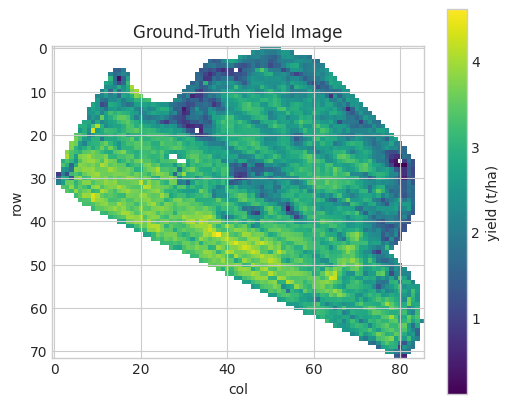

In [7]:
field_code = {name: code for code, name in field_name_mapping.items()}[FIELD_ID]
field_index = ds.index.values[ds["field_shared_name"].values == field_code]
field_ds = ds.sel(index=field_index)

field_rows = field_ds["row"].values.astype(int)
field_cols = field_ds["col"].values.astype(int)
field_target = np.full((field_rows.max() + 1, field_cols.max() + 1), np.nan, dtype=np.float32)
field_target[field_rows, field_cols] = field_ds["target"].values

print(f"Field code: {field_code}")
print(f"Pixels in field: {field_ds.sizes['index']}")
print(f"Reconstructed raster shape: {field_target.shape}")
print(f"Mean target yield: {np.nanmean(field_target):.3f} t/ha")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(field_target, cmap="viridis")
ax.set_title(f"Ground-Truth Yield Image")
ax.set_xlabel("col")
ax.set_ylabel("row")
plt.colorbar(im, ax=ax, label="yield (t/ha)")
plt.show()

In [8]:
example_pixel = field_ds.isel(index=0)
selected_bands = ["B04", "B08", "temp_mean", "total_prec", "coord_x", "coord_y"]

pixel_timeseries = pd.DataFrame({
    "time": pd.to_datetime(example_pixel["times"].values)
})
for band_name in selected_bands:
    pixel_timeseries[band_name] = example_pixel["sample"].sel(band=band_name).values

pixel_timeseries

,time,B04,B08,temp_mean,total_prec,coord_x,coord_y
0,NaT,NaN,NaN,NaN,NaN,-0.811309,-0.271778
1,NaT,NaN,NaN,NaN,NaN,-0.811309,-0.271778
2,NaT,NaN,NaN,NaN,NaN,-0.811309,-0.271778
3,NaT,NaN,NaN,NaN,NaN,-0.811309,-0.271778
4,NaT,NaN,NaN,NaN,NaN,-0.811309,-0.271778
5,NaT,NaN,NaN,NaN,NaN,-0.811309,-0.271778
6,NaT,NaN,NaN,NaN,NaN,-0.811309,-0.271778
7,NaT,NaN,NaN,NaN,NaN,-0.811309,-0.271778
8,2018-09-19,908.0,2776.0,4345.633789,0.011295,-0.811309,-0.271778
9,2018-10-19,612.0,3217.0,8861.309570,0.015924,-0.811309,-0.271778


The last table shows how one pixel is represented after preprocessing:

- Sentinel-2 bands are season-aligned across `time_step`.
- Weather values are aligned to the same time axis.
- Static features such as coordinates are repeated across the 24 time steps so they can be concatenated into one model input tensor.


## 3. Raw Per-Field Release

The raw release keeps one directory per field. This is the better format when you want to inspect or redesign the preprocessing pipeline, work with acquisition-level Sentinel-2 imagery, or choose among alternative yield-mask products.

With below structure for a country:
```bash 
Country_1                          # Unique country identifier
├── field_ID                       # Unique field identifier
│   ├── dem                        # Topography features for each pixel (10x10m resolution)
│   ├── metadata-<field_ID>.json   # Metadata for each field (crop, harvesting date, seeding date, collected yield, data curation, etc.)
│   ├── s2_images                  # Sentinel-2 images for each field between seeding and harvesting (10x10m resolution)
│   ├── scl_masks                  # SCL layer for each field between seeding and harvesting (20x20m resolution)
│   ├── soil                       # Soil features for each pixel with depth (0-200 cm) (10x10m resolution)
│   ├── weather                    # weather data between seeding and harvesting for each field
│   └── yield_masks                # Yield mask (image in 10x10m resolution)
```


In [9]:
raw_items = []
for item in sorted(field_root.iterdir()):
    if item.is_dir():
        raw_items.append(
            {
                "name": item.name + "/",
                "type": "directory",
                "n_files": len(list(item.iterdir())),
            }
        )
    else:
        raw_items.append(
            {
                "name": item.name,
                "type": "file",
                "n_files": np.nan,
            }
        )

print(f"Example number of files in a field dir for field: {field_root}")        
pd.DataFrame(raw_items)

Example number of files in a field dir for field: /yieldsat_data/original-preprocessed/Germany/Germany_DUP3_farm5_field263_rapeseed_2019


,name,type,n_files
0,dem/,directory,5.0
1,metadata-Germany_DUP3_farm5_field263_rapeseed_...,file,NaN
2,s2_images/,directory,64.0
3,scl_masks/,directory,64.0
4,soil/,directory,8.0
5,weather/,directory,1.0
6,yield_masks/,directory,3.0


In [10]:
from pprint import pprint

metadata_path = field_root / f"metadata-{FIELD_ID}.json"
metadata = json.loads(metadata_path.read_text())

pprint(metadata)

{'adm_units': {'adm_1': 'Mecklenburg-Vorpommern',
               'adm_2': 'Mecklenburgische Seenplatte',
               'country': 'Germany'},
 'area_calculated': 35.91136,
 'area_ground_truth': 39.4,
 'centroid_latitude_wgs84': 53.94825764491136,
 'centroid_longitude_wgs84': 12.889780863311204,
 'crop': 'rapeseed',
 'data_provider': 'DUP3',
 'farm_identifier': 'farm5',
 'field_shared_name': 'Germany_DUP3_farm5_field263_rapeseed_2019',
 'harvesting_date': '04.08.2019',
 'max_yield_per_hectare': 10,
 'min_yield_per_hectare': 0,
 'projected_crs_epsg': 32633,
 'quality_density': 'good',
 'seeding_date': '05.09.2018',
 'seeding_date_type': '333 days before harvest',
 'standard_moisture': 9,
 'year': 2019,
 'yield_ground_truth': 2.946,
 'yieldmap_quality': 'Good'}


### Weather Data

For each field, the raw release includes a daily weather table. The Germany example below visualizes mean, minimum, and maximum temperature together with total precipitation.


In [11]:
weather_path = field_root / "weather" / f"{FIELD_ID}.csv"
weather_df = pd.read_csv(weather_path, parse_dates=["Date"])

s2_files = sorted((field_root / "s2_images").glob("*.tif"))
scl_files = sorted((field_root / "scl_masks").glob("*.tif"))
yield_mask_path = field_root / "yield_masks" / "mean_scaled_yield_masked_regional_statistical_outlier.tif"
yield_mask = open_raster(yield_mask_path)

print(f"Weather rows: {len(weather_df)}")
print(f"Weather date range: {weather_df['Date'].min().date()} -> {weather_df['Date'].max().date()}")
print(f"Sentinel-2 acquisitions: {len(s2_files)}")
print(f"SCL masks: {len(scl_files)}")
print(f"S2 and SCL filenames are date-aligned: {[p.name.replace('S2_L2A_', '') for p in s2_files] == [p.name.replace('S2_L2A_SCL_', '') for p in scl_files]}")

weather_view = weather_df[["Date", "Temp_mean", "Temp_max", "Temp_min", "Total_prec"]].copy()
weather_view["Temp_mean"] = weather_view["Temp_mean"] - 273.15
weather_view["Temp_max"] = weather_view["Temp_max"] - 273.15
weather_view["Temp_min"] = weather_view["Temp_min"] - 273.15
weather_view["Total_prec"] = weather_view["Total_prec"] * 1000
weather_view.head()

Weather rows: 455
Weather date range: 2018-07-07 -> 2019-10-04
Sentinel-2 acquisitions: 64
SCL masks: 64
S2 and SCL filenames are date-aligned: True


,Date,Temp_mean,Temp_max,Temp_min,Total_prec
0,2018-07-07,17.71353,22.06265,12.18447,0.000000
1,2018-07-08,19.99105,24.06460,15.70327,1.900673
2,2018-07-09,16.68777,19.45327,13.68105,0.395775
3,2018-07-10,15.63190,18.38223,11.48390,1.466751
4,2018-07-11,16.93002,18.11917,15.71572,28.768540


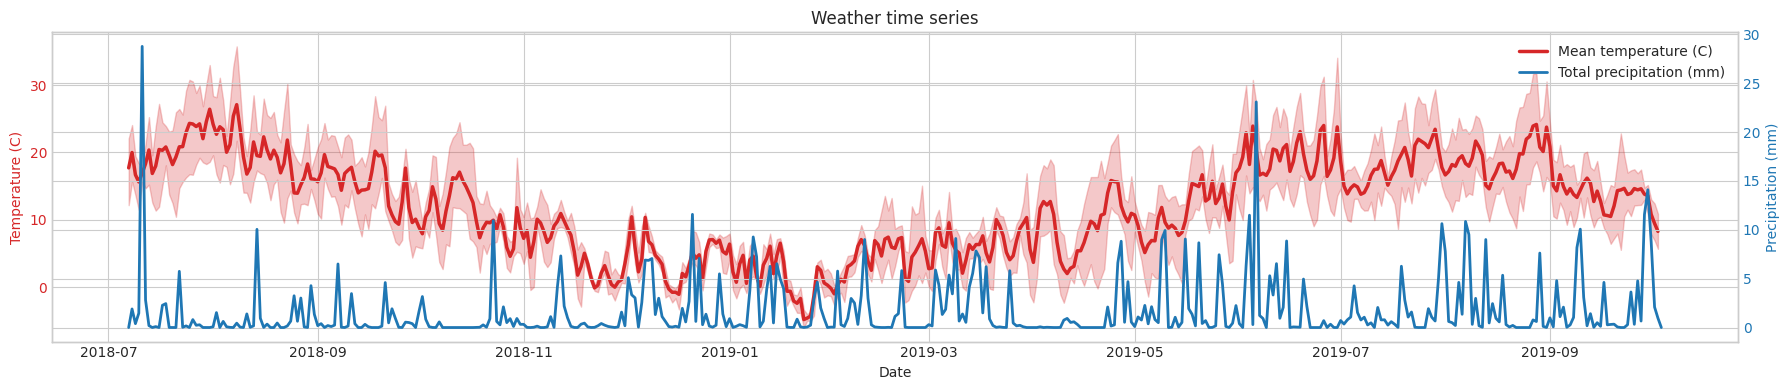

In [12]:
fig, ax1 = plt.subplots(figsize=(18, 4))

ax1.plot(weather_view["Date"], weather_view["Temp_mean"], c="tab:red", linewidth=2.5, label="Mean temperature (C)")
ax1.fill_between(
    weather_view["Date"],
    weather_view["Temp_min"],
    weather_view["Temp_max"],
    color="tab:red",
    alpha=0.25,
    label="Temperature range",
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Temperature (C)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.plot(weather_view["Date"], weather_view["Total_prec"], c="tab:blue", linewidth=2.0, label="Total precipitation (mm)")
ax2.set_ylabel("Precipitation (mm)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right")
ax1.set_title("Weather time series")
plt.tight_layout()
plt.show()

### Multispectral Sentinel-2 Time Series

The raw field folder stores the acquisition-level Sentinel-2 imagery. The panel below shows a subsampled RGB time series together with the yield mask for reference.


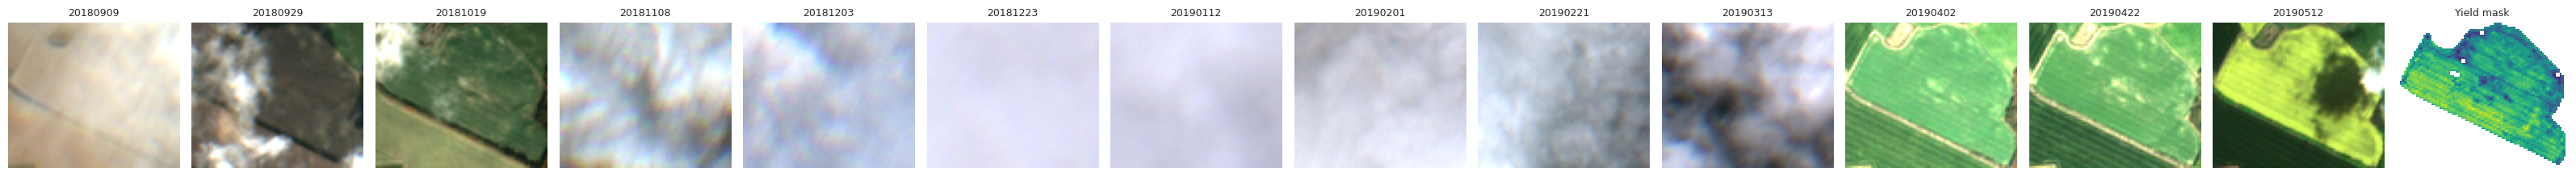

Size of each S2 image in Germany_DUP3_farm5_field263_rapeseed_2019: 73 x 86


In [13]:
s2_subset = s2_files[::4][:13]
fig, axs = plt.subplots(1, 14, figsize=(32, 32), sharex=True)

for ax in axs:
    ax.axis("off")
    ax.set_xticks([])
    ax.set_yticks([])

for j, s2_path in enumerate(s2_subset):
    s2_rgb = read_rgb(s2_path)
    axs[j].imshow(s2_rgb)
    axs[j].set_title(s2_path.stem[-8:], fontsize=9)

axs[-1].imshow(yield_mask, cmap="viridis")
axs[-1].set_title("Yield mask", fontsize=9)

plt.tight_layout()
plt.show()

print(f"Size of each S2 image in {FIELD_ID}: {s2_rgb.shape[0]} x {s2_rgb.shape[1]}")

### Topography: Digital Elevation Model Features

Each field includes five DEM-derived rasters aligned to the same grid as the Sentinel-2 imagery and yield mask.


In [14]:
dem_dir = field_root / "dem"
dem_paths = sorted(dem_dir.glob("*.tif"))
print([path.name for path in dem_paths])

['aspect-Germany_DUP3_farm5_field263_rapeseed_2019.tif', 'curvature-Germany_DUP3_farm5_field263_rapeseed_2019.tif', 'dem-Germany_DUP3_farm5_field263_rapeseed_2019.tif', 'slope-Germany_DUP3_farm5_field263_rapeseed_2019.tif', 'twi-Germany_DUP3_farm5_field263_rapeseed_2019.tif']


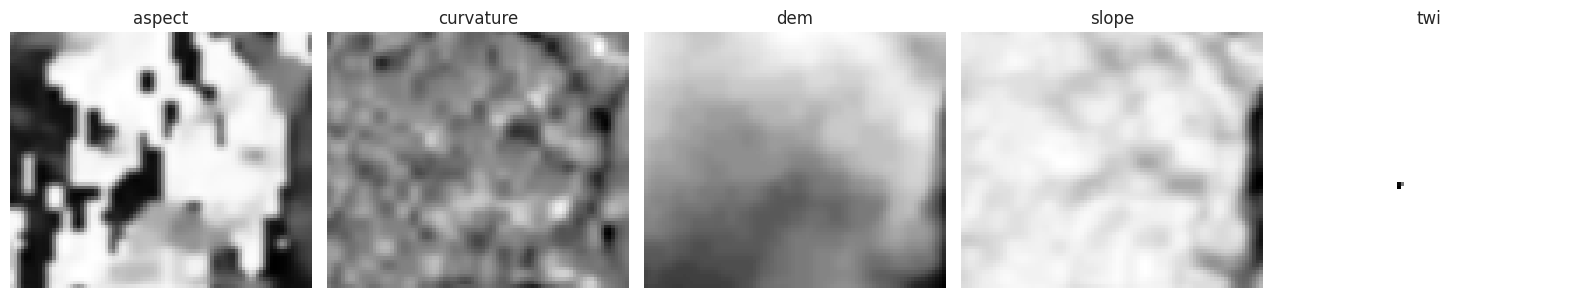

Size of each DEM feature in Germany_DUP3_farm5_field263_rapeseed_2019: 73 x 86


In [15]:
fig, axs = plt.subplots(1, 5, figsize=(16, 3.8))
dem_arrays = {}

for ax, dem_path in zip(axs, dem_paths):
    feature_name = dem_path.stem.split("-")[0]
    dem_array = open_raster(dem_path)
    dem_arrays[feature_name] = dem_array
    ax.imshow(dem_array)
    ax.set_title(feature_name)
    ax.axis("off")

plt.tight_layout()
plt.show()
print(f"Size of each DEM feature in {FIELD_ID}: {dem_arrays['dem'].shape[0]} x {dem_arrays['dem'].shape[1]}")

### Soil Data

The soil folder contains eight static rasters aligned with the same field grid. The plot below reproduces the full set of soil layers in a compact 2 x 4 layout.


In [16]:
soil_dir = field_root / "soil"
soil_paths = sorted(soil_dir.glob("*.tif"))
print([path.name for path in soil_paths])

['cec_0_200cm-Germany_DUP3_farm5_field263_rapeseed_2019.tif', 'cfvo_0_200cm-Germany_DUP3_farm5_field263_rapeseed_2019.tif', 'clay_0_200cm-Germany_DUP3_farm5_field263_rapeseed_2019.tif', 'nitrogen_0_200cm-Germany_DUP3_farm5_field263_rapeseed_2019.tif', 'phh2o_0_200cm-Germany_DUP3_farm5_field263_rapeseed_2019.tif', 'sand_0_200cm-Germany_DUP3_farm5_field263_rapeseed_2019.tif', 'silt_0_200cm-Germany_DUP3_farm5_field263_rapeseed_2019.tif', 'soc_0_200cm-Germany_DUP3_farm5_field263_rapeseed_2019.tif']


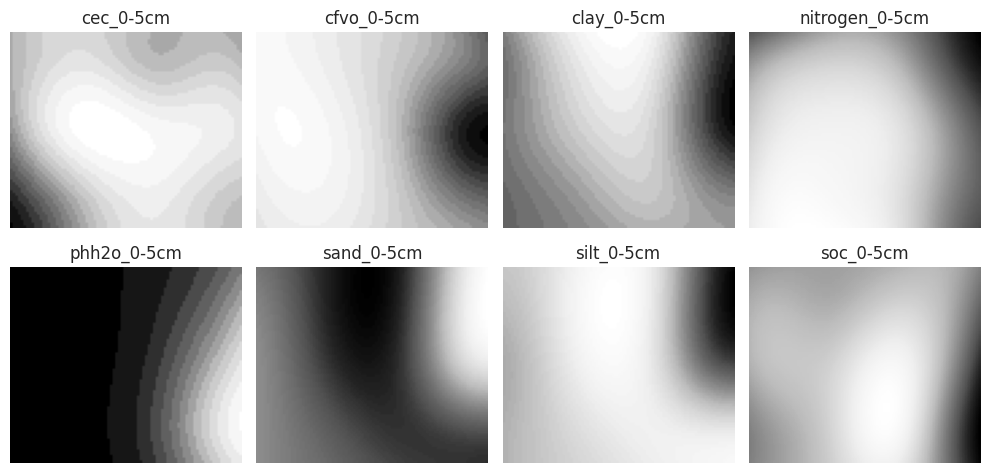

Size of each soil feature in Germany_DUP3_farm5_field263_rapeseed_2019: 73 x 86


In [17]:
fig, axs = plt.subplots(2, 4, figsize=(10, 5))

cec_0_200cm = open_raster(soil_dir / f"cec_0_200cm-{FIELD_ID}.tif")
axs[0, 0].imshow(cec_0_200cm)
axs[0, 0].set_title("cec_0-5cm")

cfvo_0_200cm = open_raster(soil_dir / f"cfvo_0_200cm-{FIELD_ID}.tif")
axs[0, 1].imshow(cfvo_0_200cm)
axs[0, 1].set_title("cfvo_0-5cm")

clay_0_200cm = open_raster(soil_dir / f"clay_0_200cm-{FIELD_ID}.tif")
axs[0, 2].imshow(clay_0_200cm)
axs[0, 2].set_title("clay_0-5cm")

nitrogen_0_200cm = open_raster(soil_dir / f"nitrogen_0_200cm-{FIELD_ID}.tif")
axs[0, 3].imshow(nitrogen_0_200cm)
axs[0, 3].set_title("nitrogen_0-5cm")

phh2o_0_200cm = open_raster(soil_dir / f"phh2o_0_200cm-{FIELD_ID}.tif")
axs[1, 0].imshow(phh2o_0_200cm)
axs[1, 0].set_title("phh2o_0-5cm")

sand_0_200cm = open_raster(soil_dir / f"sand_0_200cm-{FIELD_ID}.tif")
axs[1, 1].imshow(sand_0_200cm)
axs[1, 1].set_title("sand_0-5cm")

silt_0_200cm = open_raster(soil_dir / f"silt_0_200cm-{FIELD_ID}.tif")
axs[1, 2].imshow(silt_0_200cm)
axs[1, 2].set_title("silt_0-5cm")

soc_0_200cm = open_raster(soil_dir / f"soc_0_200cm-{FIELD_ID}.tif")
axs[1, 3].imshow(soc_0_200cm)
axs[1, 3].set_title("soc_0-5cm")

for ax in axs.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()
print(f"Size of each soil feature in {FIELD_ID}: {soc_0_200cm.shape[0]} x {soc_0_200cm.shape[1]}")

## 4. Choosing the Right Format

Use `preprocessed-24-ts/` when you want a standardized model-ready benchmark input.

Use `original-preprocessed/` when you want to:

- inspect the original field-level files,
- work with full Sentinel-2 acquisition sequences and paired SCL masks,
- access the raw weather CSV and static raster layers directly, or
- build your own preprocessing and fusion pipeline.
